# Phase 0 — Iris pipeline spike

**Goal:** Prove that Worldcoin's `open-iris` pipeline runs end-to-end on this machine, visualize each intermediate stage, and demonstrate numerically that iris codes from the **same eye** are closer in Hamming distance than iris codes from **different eyes**.

This notebook is deliberately teaching-shaped. If you're coming from a TypeScript/Next.js background, the mental model is:

- The pipeline is a DAG — think of it as a sequence of pure-ish functions where each stage consumes the previous stage's output.
- Each "stage" is a Python object with a `run(...)` method. `open-iris` wires them up by name using a YAML config.
- The only ML block is the segmentation model (a MobileNetV2 UNet exported to ONNX, loaded via `onnxruntime`). Everything after it — polygon fitting, rubber-sheet normalization, Gabor filtering, bit quantization — is classical image processing and linear algebra.

Read top to bottom. Every cell depends on the one above it.

## 0. Environment check

Kernel must be this repo's `.venv` (Python 3.10) with `open-iris` installed. If the import below fails, re-read `notebooks/README.md` and rerun the setup commands.

In [1]:
import platform
import iris
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import defaultdict

print('python:', platform.python_version())
print('iris  :', iris.__version__)
print('cv2   :', cv2.__version__)
print('numpy :', np.__version__)

python: 3.10.20
iris  : 1.11.1
cv2   : 4.7.0
numpy : 1.24.4


## 1. Data

Two sources, both pulled on first run:

1. **Worldcoin's public iris samples** (3 near-infrared images used by `open-iris`'s own `MatchingEntities.ipynb` demo). Two captures of one subject + one of a second subject.
2. **MMU iris database** (Multimedia University, Malaysia) — 45 subjects × ~4 NIR captures per left eye; we pull a 4-subject, 16-image subset from a public GitHub mirror. Image size 320×240, grayscale, academic research use.

Files land in `notebooks/data/`, which is **gitignored** — biometric images are not committed. Re-running the cell below is a no-op once the files are present.

In [2]:
import urllib.request

DATA_DIR = Path('data')
MMU_DIR  = DATA_DIR / 'mmu'
WLD_DIR  = DATA_DIR / 'worldcoin'
MMU_DIR.mkdir(parents=True, exist_ok=True)
WLD_DIR.mkdir(parents=True, exist_ok=True)

def fetch(url, dest):
    if dest.exists() and dest.stat().st_size > 0:
        return
    req = urllib.request.Request(url, headers={'User-Agent': 'tanik-phase-0/1'})
    with urllib.request.urlopen(req, timeout=30) as r, open(dest, 'wb') as f:
        f.write(r.read())

WLD_BASE = 'https://wld-ml-ai-data-public.s3.amazonaws.com/public-iris-images'
for n, label in [(1, 'subject_1_a'), (2, 'subject_1_b'), (3, 'subject_2_a')]:
    fetch(f'{WLD_BASE}/example_orb_image_{n}.png', WLD_DIR / f'{label}.png')

MMU_BASE = 'https://raw.githubusercontent.com/emrealtann/IrisRecognition/master/MMU'
MMU_SUBJECTS = {
    'subj_christine': ('0', ['christinel1.bmp', 'christinel2.bmp', 'christinel3.bmp', 'christinel4.bmp']),
    'subj_aeva'     : ('1', ['aeval1.bmp',      'aeval2.bmp',      'aeval3.bmp',      'aeval4.bmp']),
    'subj_bryan'    : ('2', ['bryanl1.bmp',     'bryanl2.bmp',     'bryanl3.bmp',     'bryanl4.bmp']),
    'subj_chingyc'  : ('3', ['chingycl1.bmp',   'chingycl2.bmp',   'chingycl3.bmp',   'chingycl4.bmp']),
}
for label, (d, files) in MMU_SUBJECTS.items():
    for fname in files:
        fetch(f'{MMU_BASE}/{d}/{fname}', MMU_DIR / f'{label}_{fname}')

print('Worldcoin:', sorted(p.name for p in WLD_DIR.iterdir()))
print('MMU      :', sorted(p.name for p in MMU_DIR.iterdir()))

Worldcoin: ['subject_1_a.png', 'subject_1_b.png', 'subject_2_a.png']
MMU      : ['subj_aeva_aeval1.bmp', 'subj_aeva_aeval2.bmp', 'subj_aeva_aeval3.bmp', 'subj_aeva_aeval4.bmp', 'subj_bryan_bryanl1.bmp', 'subj_bryan_bryanl2.bmp', 'subj_bryan_bryanl3.bmp', 'subj_bryan_bryanl4.bmp', 'subj_chingyc_chingycl1.bmp', 'subj_chingyc_chingycl2.bmp', 'subj_chingyc_chingycl3.bmp', 'subj_chingyc_chingycl4.bmp', 'subj_christine_christinel1.bmp', 'subj_christine_christinel2.bmp', 'subj_christine_christinel3.bmp', 'subj_christine_christinel4.bmp']


## 2. The pipeline at a glance

`iris.IRISPipeline()` constructs a DAG of 20+ stages. The ones that matter conceptually:

| Stage | What it produces |
|---|---|
| `segmentation` | 4-channel per-pixel probability map: eyeball / iris / pupil / eyelashes |
| `segmentation_binarization` | Hard binary masks for the above |
| `geometry_estimation` | Pupil and iris polygons (circle / ellipse fit) |
| `normalization` | The iris unrolled from the disc into a fixed 128×512 rectangle — Daugman's rubber-sheet model |
| `filter_bank` | Convolution of the normalized iris with a bank of 2-D Gabor filters |
| `encoder` | Binarized Gabor responses → the **iris code** (what we match on) |

Runs serially on CPU. One image takes a few seconds on a modern laptop.

The pipeline object keeps every intermediate in `.call_trace`, keyed by stage name. That's what we'll use to visualize.

In [3]:
pipeline = iris.IRISPipeline()
print('Default pipeline nodes (in execution order):')
for name in pipeline.call_trace._storage:
    if name not in ('input', 'error'):
        print('  -', name)

Default pipeline nodes (in execution order):
  - segmentation
  - segmentation_binarization
  - vectorization
  - specular_reflection_detection
  - interpolation
  - distance_filter
  - eye_orientation
  - eye_center_estimation
  - eye_centers_inside_image_validator
  - smoothing
  - geometry_estimation
  - pupil_to_iris_property_estimation
  - offgaze_estimation
  - occlusion90_calculator
  - occlusion30_calculator
  - noise_masks_aggregation
  - normalization
  - sharpness_estimation
  - filter_bank
  - iris_response_refinement
  - encoder
  - bounding_box_estimation


## 3. Load a walk-through iris

One MMU capture, one pipeline run. MMU images are 320×240 grayscale BMPs; `open-iris` expects near-infrared grayscale input and MMU fits that.

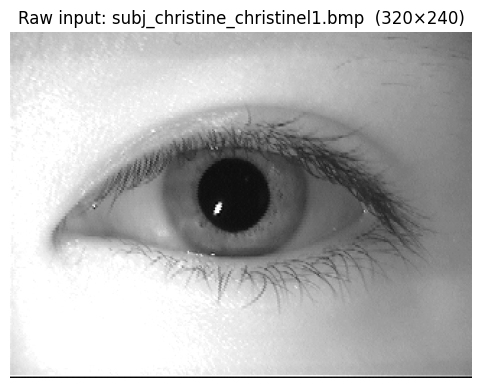

dtype: uint8  min/max: 2 248


In [4]:
walk_path = MMU_DIR / 'subj_christine_christinel1.bmp'
walk_img = cv2.imread(str(walk_path), cv2.IMREAD_GRAYSCALE)
assert walk_img is not None, f'Failed to read {walk_path}'

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(walk_img, cmap='gray')
ax.set_title(f'Raw input: {walk_path.name}  ({walk_img.shape[1]}×{walk_img.shape[0]})')
ax.axis('off')
plt.show()
print('dtype:', walk_img.dtype, ' min/max:', walk_img.min(), walk_img.max())

## 4. Run the pipeline

Calling the pipeline fills `pipeline.call_trace` with every stage's output. The dict returned to us contains `iris_template` (the thing we match on) and `error` (populated if any stage raised).

In [5]:
walk_output = pipeline(iris.IRImage(img_data=walk_img, image_id=walk_path.stem, eye_side='left'))
assert walk_output['error'] is None, f"pipeline error: {walk_output['error']}"
print('pipeline returned keys:', list(walk_output.keys()))
print('iris template produced:', walk_output['iris_template'] is not None)

pipeline returned keys: ['error', 'iris_template', 'metadata']
iris template produced: True


### 4a. Segmentation

The only ML stage. A MobileNetV2 UNet (ONNX) emits four probability maps. Everything downstream is deterministic classical processing.

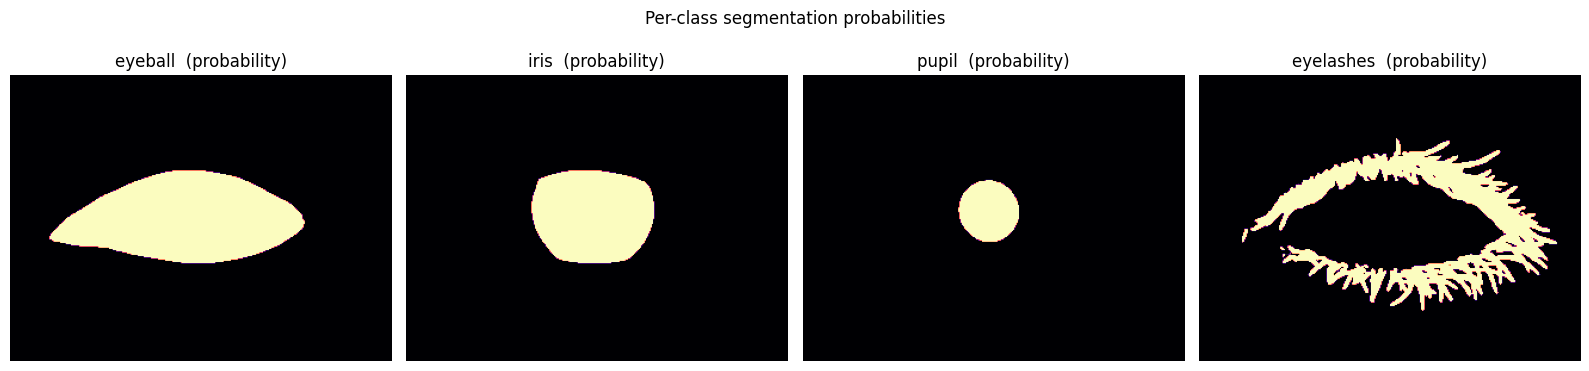

In [6]:
seg = pipeline.call_trace['segmentation']
classes = seg.index2class     # e.g. {0:'eyeball', 1:'iris', 2:'pupil', 3:'eyelashes'}
preds = seg.predictions       # H x W x 4

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ch in range(4):
    axes[ch].imshow(preds[..., ch], cmap='magma', vmin=0, vmax=1)
    axes[ch].set_title(f'{classes[ch]}  (probability)')
    axes[ch].axis('off')
plt.suptitle('Per-class segmentation probabilities')
plt.tight_layout()
plt.show()

### 4b. Geometry — fitted polygons

After binarization, the pipeline fits the iris outer boundary, the pupil boundary, and the eyeball. These polygons define where to unroll the iris from in the next stage.

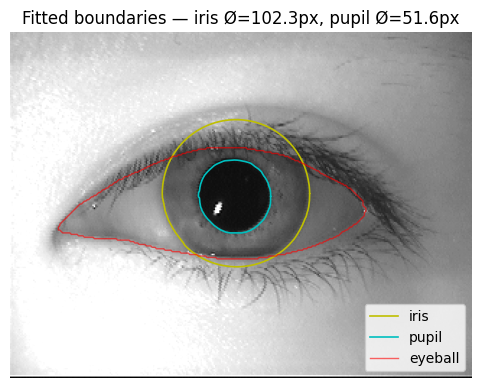

In [7]:
geom = pipeline.call_trace['geometry_estimation']
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(walk_img, cmap='gray')
ax.plot(geom.iris_array[:, 0],    geom.iris_array[:, 1],    'y-', lw=1.2, label='iris')
ax.plot(geom.pupil_array[:, 0],   geom.pupil_array[:, 1],   'c-', lw=1.2, label='pupil')
ax.plot(geom.eyeball_array[:, 0], geom.eyeball_array[:, 1], 'r-', lw=1.0, alpha=0.6, label='eyeball')
ax.set_title(f'Fitted boundaries — iris Ø={geom.iris_diameter:.1f}px, pupil Ø={geom.pupil_diameter:.1f}px')
ax.axis('off')
ax.legend(loc='lower right')
plt.show()

### 4c. Normalization — the rubber-sheet

Daugman's 1993 trick. The iris is a circular annulus. Unroll it into polar coordinates and you get a fixed-size rectangle (128×512 here). Two different captures of the same eye — even at different zoom, rotation, or pupil dilation — end up in a comparable canonical form.

`open-iris` uses perspective normalization (a slight refinement of the basic polar unwrap) and masks out occluded pixels.

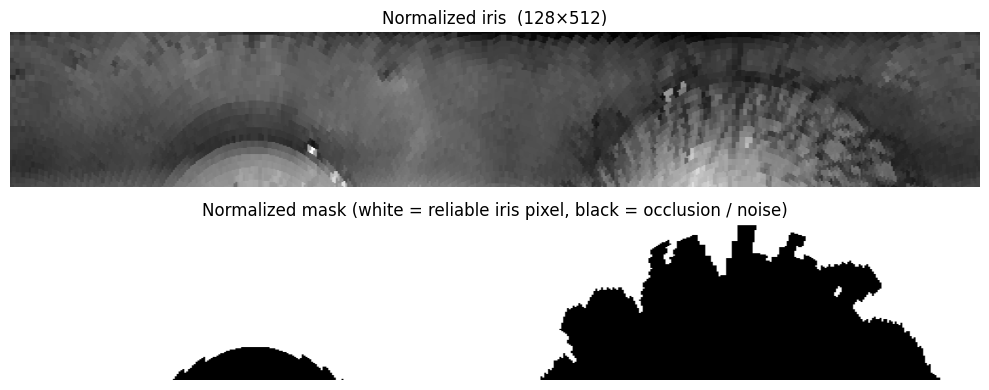

In [8]:
norm = pipeline.call_trace['normalization']
fig, axes = plt.subplots(2, 1, figsize=(10, 4))
axes[0].imshow(norm.normalized_image, cmap='gray', aspect='auto')
axes[0].set_title(f'Normalized iris  ({norm.normalized_image.shape[0]}×{norm.normalized_image.shape[1]})')
axes[0].axis('off')
axes[1].imshow(norm.normalized_mask,  cmap='gray', aspect='auto')
axes[1].set_title('Normalized mask (white = reliable iris pixel, black = occlusion / noise)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 4d. The iris code

A bank of 2-D Gabor filters is convolved with the normalized iris. At each sample point, the filter's complex response has a phase; that phase is quantized to 2 bits (which quadrant of the complex plane it falls in). The collection of those bits **is** the iris code.

The default config uses 2 filters and samples on a 16×256 grid, giving 2 × 16 × 256 × 2 = **16 384 bits** per iris. The corresponding mask marks which bits are usable.

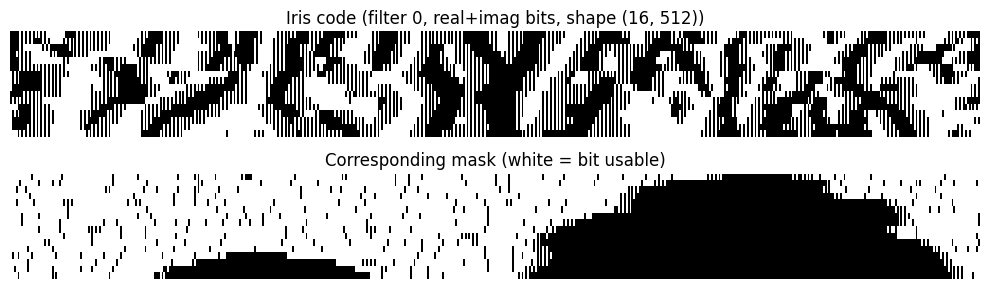

Total bits in template: 16384  (2 filters × 16 × 256 × 2)


In [9]:
tpl   = pipeline.call_trace['encoder']
code0 = np.asarray(tpl.iris_codes[0]).astype(np.uint8)   # (16, 256, 2)
mask0 = np.asarray(tpl.mask_codes[0]).astype(np.uint8)
bits  = code0.reshape(code0.shape[0], -1)                 # (16, 512)

fig, axes = plt.subplots(2, 1, figsize=(10, 3))
axes[0].imshow(bits, cmap='gray', aspect='auto', interpolation='nearest')
axes[0].set_title(f'Iris code (filter 0, real+imag bits, shape {bits.shape})')
axes[0].axis('off')
axes[1].imshow(mask0.reshape(mask0.shape[0], -1), cmap='gray', aspect='auto', interpolation='nearest')
axes[1].set_title('Corresponding mask (white = bit usable)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

total = sum(np.asarray(c).size for c in tpl.iris_codes)
print(f'Total bits in template: {total}  (2 filters × {code0.shape[0]} × {code0.shape[1]} × 2)')

## 5. Matching — Hamming distance between two iris codes

Two iris codes are compared by **masked fractional Hamming distance**:

> fraction of bits that disagree, counted only over positions where both masks say the bit is usable.

Interpretation:

- 0.0 → perfect match (identical iris code).
- ~0.5 → two statistically-independent irises (a fair coin, essentially). If two strangers came out much below 0.5, the iris code would not be carrying enough information.
- `open-iris` recommends an operating threshold around 0.34–0.39.

`HammingDistanceMatcher` also tries small rotational shifts (to tolerate head tilt) and returns the best match found.

### 5a. Sanity check on the Worldcoin samples

Before running the bigger MMU experiment, reproduce `open-iris`'s own `MatchingEntities.ipynb` result: two captures of subject 1 should match; subject 1 vs subject 2 should not.

In [10]:
def encode(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(img_path)
    p = iris.IRISPipeline()
    out = p(iris.IRImage(img_data=img, image_id=img_path.stem, eye_side='left'))
    if out['error'] is not None:
        raise RuntimeError(f"pipeline error on {img_path.name}: {out['error']}")
    return out['iris_template']

matcher = iris.HammingDistanceMatcher()

w1a = encode(WLD_DIR / 'subject_1_a.png')
w1b = encode(WLD_DIR / 'subject_1_b.png')
w2a = encode(WLD_DIR / 'subject_2_a.png')

print(f'subject1_a  vs subject1_b  (same eye)     HD = {matcher.run(w1a, w1b):.4f}')
print(f'subject1_a  vs subject2_a  (different)    HD = {matcher.run(w1a, w2a):.4f}')
print(f'subject1_b  vs subject2_a  (different)    HD = {matcher.run(w1b, w2a):.4f}')

subject1_a  vs subject1_b  (same eye)     HD = 0.1485
subject1_a  vs subject2_a  (different)    HD = 0.4496
subject1_b  vs subject2_a  (different)    HD = 0.4603


### 5b. MMU — every same-eye and different-eye pair

Encode all 16 MMU images once (slow — CPU pipeline, ~a minute), then form:

- **same-eye pairs:** every pair of distinct captures within the same subject. With 4 subjects × 4 captures each, that's 4 × C(4,2) = **24 pairs**.
- **different-eye pairs:** one capture each from two different subjects. C(4,2) × 4 × 4 = **96 pairs**.

Plenty to show the distribution.

In [11]:
mmu_templates = defaultdict(list)  # subject -> [(filename, template), ...]
for subject_label in sorted(MMU_SUBJECTS):
    for path in sorted(MMU_DIR.glob(f'{subject_label}_*.bmp')):
        print(f'encoding {path.name} ...')
        mmu_templates[subject_label].append((path.name, encode(path)))

total = sum(len(v) for v in mmu_templates.values())
print(f'\n{total} MMU templates across {len(mmu_templates)} subjects.')

encoding subj_aeva_aeval1.bmp ...


encoding subj_aeva_aeval2.bmp ...


encoding subj_aeva_aeval3.bmp ...


encoding subj_aeva_aeval4.bmp ...


encoding subj_bryan_bryanl1.bmp ...


...

encoding subj_christine_christinel1.bmp ...


encoding subj_christine_christinel2.bmp ...


encoding subj_christine_christinel3.bmp ...


encoding subj_christine_christinel4.bmp ...



16 MMU templates across 4 subjects.


In [12]:
same_pairs, diff_pairs = [], []

for subj, items in mmu_templates.items():
    for (n1, t1), (n2, t2) in combinations(items, 2):
        same_pairs.append((subj, n1, n2, matcher.run(t1, t2)))

subjects = list(mmu_templates.items())
for (sA, itemsA), (sB, itemsB) in combinations(subjects, 2):
    for (nA, tA) in itemsA:
        for (nB, tB) in itemsB:
            diff_pairs.append((sA, nA, sB, nB, matcher.run(tA, tB)))

print(f'same-eye pairs      : {len(same_pairs)}')
print(f'different-eye pairs : {len(diff_pairs)}')
print()
print('All same-eye pairs:')
for subj, n1, n2, d in same_pairs:
    print(f'  {subj:18s}  {n1[-18:]:18s} ↔ {n2[-18:]:18s}  HD = {d:.4f}')
print()
print('First 12 different-eye pairs:')
for sA, nA, sB, nB, d in diff_pairs[:12]:
    print(f'  {sA:14s} ↔ {sB:14s}  HD = {d:.4f}')

same-eye pairs      : 24
different-eye pairs : 96

All same-eye pairs:
  subj_aeva           bj_aeva_aeval1.bmp ↔ bj_aeva_aeval2.bmp  HD = 0.0673
  subj_aeva           bj_aeva_aeval1.bmp ↔ bj_aeva_aeval3.bmp  HD = 0.0616
  subj_aeva           bj_aeva_aeval1.bmp ↔ bj_aeva_aeval4.bmp  HD = 0.0666
  subj_aeva           bj_aeva_aeval2.bmp ↔ bj_aeva_aeval3.bmp  HD = 0.0631
  subj_aeva           bj_aeva_aeval2.bmp ↔ bj_aeva_aeval4.bmp  HD = 0.0661
  subj_aeva           bj_aeva_aeval3.bmp ↔ bj_aeva_aeval4.bmp  HD = 0.0543
  subj_bryan          _bryan_bryanl1.bmp ↔ _bryan_bryanl2.bmp  HD = 0.2040
  subj_bryan          _bryan_bryanl1.bmp ↔ _bryan_bryanl3.bmp  HD = 0.1767
  subj_bryan          _bryan_bryanl1.bmp ↔ _bryan_bryanl4.bmp  HD = 0.1398
  subj_bryan          _bryan_bryanl2.bmp ↔ _bryan_bryanl3.bmp  HD = 0.1512
  subj_bryan          _bryan_bryanl2.bmp ↔ _bryan_bryanl4.bmp  HD = 0.1638
  subj_bryan          _bryan_bryanl3.bmp ↔ _bryan_bryanl4.bmp  HD = 0.0974
  subj_chingyc        ngyc_ch

### 5c. Do they separate?

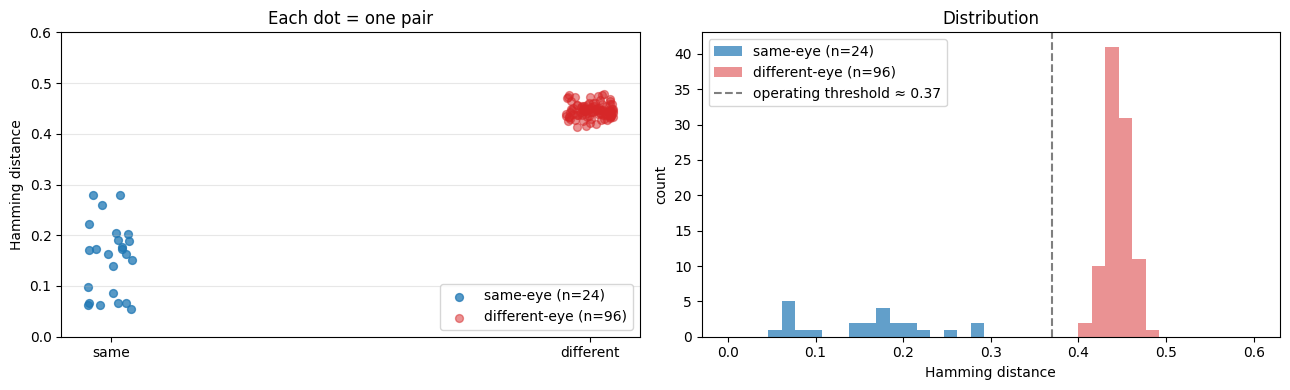

same-eye      : min=0.054  median=0.167  max=0.280
different-eye : min=0.414  median=0.445  max=0.479

Separation (median diff − median same) = 0.278
All same-eye below operating threshold (0.37)?  True
All different-eye above operating threshold?    True


In [13]:
same_d = np.array([d for *_, d in same_pairs])
diff_d = np.array([d for *_, d in diff_pairs])

rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(rng.uniform(-0.05, 0.05, same_d.shape) + 0, same_d,
                alpha=0.75, s=32, color='tab:blue', label=f'same-eye (n={len(same_d)})')
axes[0].scatter(rng.uniform(-0.05, 0.05, diff_d.shape) + 1, diff_d,
                alpha=0.5,  s=32, color='tab:red',  label=f'different-eye (n={len(diff_d)})')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['same', 'different'])
axes[0].set_ylabel('Hamming distance')
axes[0].set_title('Each dot = one pair')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 0.6)

bins = np.linspace(0, 0.6, 40)
axes[1].hist(same_d, bins=bins, alpha=0.7, color='tab:blue', label=f'same-eye (n={len(same_d)})')
axes[1].hist(diff_d, bins=bins, alpha=0.5, color='tab:red',  label=f'different-eye (n={len(diff_d)})')
axes[1].set_xlabel('Hamming distance'); axes[1].set_ylabel('count')
axes[1].set_title('Distribution')
axes[1].axvline(0.37, color='black', linestyle='--', alpha=0.5, label='operating threshold ≈ 0.37')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f'same-eye      : min={same_d.min():.3f}  median={np.median(same_d):.3f}  max={same_d.max():.3f}')
print(f'different-eye : min={diff_d.min():.3f}  median={np.median(diff_d):.3f}  max={diff_d.max():.3f}')
print(f'\nSeparation (median diff − median same) = {np.median(diff_d) - np.median(same_d):.3f}')
print(f'All same-eye below operating threshold (0.37)?  {(same_d < 0.37).all()}')
print(f'All different-eye above operating threshold?    {(diff_d > 0.37).all()}')

## 6. What this teaches

Working up from the plot: every blue dot (same eye) sits well below every red dot (different eye). That gap is the entire biometric premise — if it ever disappears, iris recognition does not work.

A few things worth internalizing before moving on:

- **Hamming distance of ~0.5 between strangers is not a bug; it is the headline result.** It's the expected value if iris codes behave like random binary strings. The fact that same-eye distances cluster well below 0.5 is what makes iris codes biometrically useful.
- **The threshold is a policy choice.** The 0.37 line here is what `open-iris` suggests; stricter thresholds reduce false accepts at the cost of false rejects, and vice versa. Phase 3 will measure FAR/FRR as a function of threshold on a proper test set — those numbers do not come from this notebook.
- **Masks matter.** Eyelashes and specular reflections occlude bits. `HammingDistanceMatcher` uses the mask-aware fractional HD; ignoring masks makes every distance noisier.
- **MMU is small and clean.** These numbers are the best case. Real-world captures (off-axis gaze, poor focus, partial occlusion) compress the gap. Phase 3's dataset will be harder.

On to Phase 1 — wrapping this exact pipeline behind a FastAPI endpoint.